In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/cclass.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/unclean cclass.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/focus.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/audi.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/toyota.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/skoda.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/ford.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/vauxhall.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/bmw.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/vw.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/hyundi.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/unclean focus.csv


https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
audi = pd.read_csv('/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/audi.csv')
bmw = pd.read_csv('/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/bmw.csv')
pd.concat([audi,bmw])

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [4]:
# This will print every folder available in your input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)


/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/adityadesai13
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes


In [5]:
data_path = "/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes"

dosyalar = os.listdir(data_path)
liste = []

for dosya in dosyalar:
    # Use os.path.join to avoid slash errors
    full_path = os.path.join(data_path, dosya)
    
    # Only read if it is a CSV file
    if dosya.endswith(".csv"):
        tablo = pd.read_csv(full_path)
        if "tax" in tablo.columns:
            liste.append(tablo)

df = pd.concat(liste, ignore_index=True)
print(f"Successfully loaded {len(liste)} files!")

Successfully loaded 8 files!


# EDA and Feature Engineering

In [6]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [7]:
df.shape

(94327, 9)

In [8]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,94327.000000,94327.000000,94327.000000,94327.000000,94327.000000,94327.000000
mean,2017.086698,17014.284150,23139.952749,120.256183,55.235816,1.673861
std,2.133897,9981.390386,21307.588875,63.404805,16.291667,0.562523
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10199.000000,7368.000000,125.000000,47.100000,1.300000
50%,2017.000000,14599.000000,17460.000000,145.000000,54.300000,1.600000
75%,2019.000000,20998.000000,32456.500000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94327 entries, 0 to 94326
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         94327 non-null  object 
 1   year          94327 non-null  int64  
 2   price         94327 non-null  int64  
 3   transmission  94327 non-null  object 
 4   mileage       94327 non-null  int64  
 5   fuelType      94327 non-null  object 
 6   tax           94327 non-null  int64  
 7   mpg           94327 non-null  float64
 8   engineSize    94327 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 6.5+ MB


In [10]:
# Count total duplicate rows
total_duplicates = df.duplicated().sum()
print(total_duplicates)

1389


# After drop Dupl

In [11]:
# 1. Store the original number of rows
original_count = len(df)

# 2. Create the cleaned version
df = df.drop_duplicates()

# 3. Compare the counts
if len(df) < original_count:
    removed = original_count - len(df)
    print(f"Success! Found and removed {removed} duplicate rows.")
else:
    print("No duplicates were found. Your data is already clean!")

Success! Found and removed 1389 duplicate rows.


In [12]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [13]:
df['transmission'].value_counts()

transmission
Manual       51956
Semi-Auto    21728
Automatic    19247
Other            7
Name: count, dtype: int64

In [14]:
df['fuelType'].value_counts()

fuelType
Petrol      51144
Diesel      38824
Hybrid       2719
Other         245
Electric        6
Name: count, dtype: int64

In [15]:
# 1. Filter the data to exclude 'Other' from tansmission
df = df[df['transmission'] != 'Other']
# 2. Filter the data to exclude 'Electric' from fuelType
df = df[df['fuelType'] != 'Electric']


In [16]:
print(df['fuelType'].value_counts(normalize=True) * 100)

fuelType
Petrol    55.034705
Diesel    41.777778
Hybrid     2.924939
Other      0.262577
Name: proportion, dtype: float64


In [17]:
df['year'].value_counts()

year
2019    25129
2017    20444
2016    15011
2018    12592
2015     7251
2020     3881
2014     3873
2013     2472
2012      611
2011      413
2010      315
2009      264
2008      195
2007      157
2006       85
2005       68
2004       52
2003       31
2002       30
2001       20
1998        8
2000        8
1999        6
1997        4
1996        2
1970        2
2060        1
Name: count, dtype: int64

In [18]:
df = df[(df['year'] >= 2007) & (df['year'] <= 2025)]

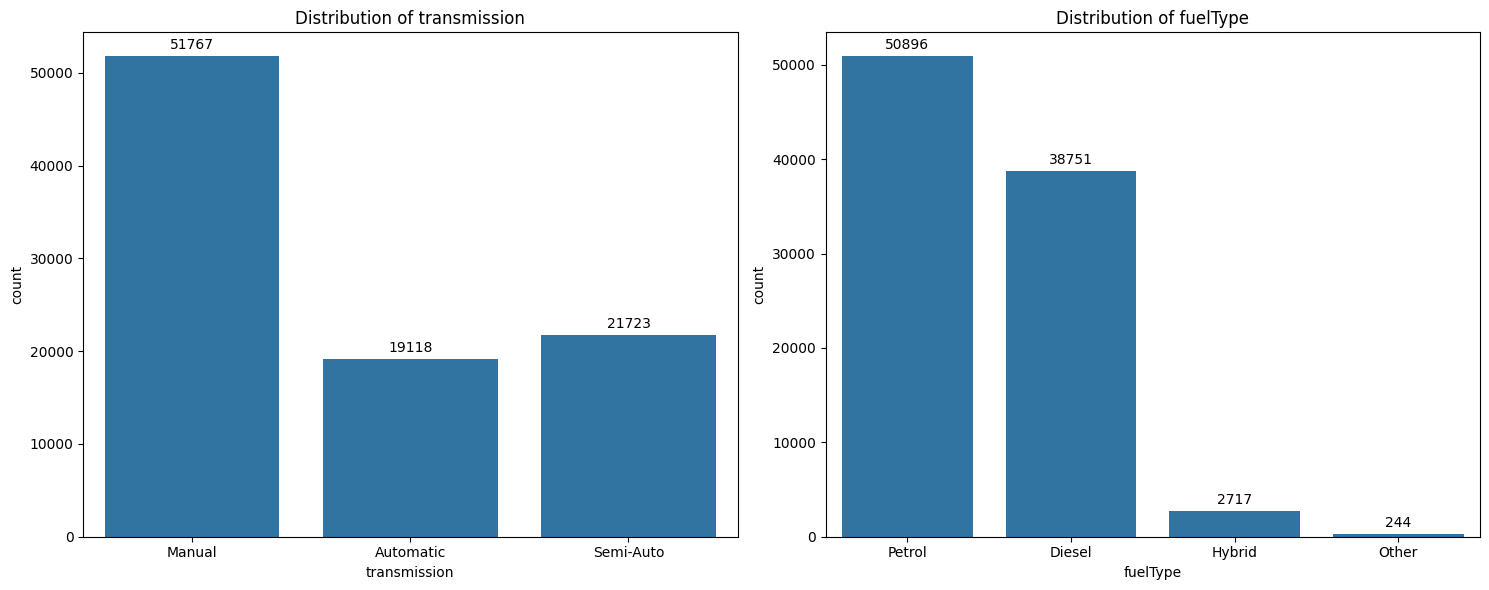

In [19]:
# 1. Define the columns
cols_to_plot = ['transmission', 'fuelType']

# 2. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Width - 15 , height - 6

for i, col in enumerate(cols_to_plot):
    # Specify which 'ax' (subplot) to draw on using axes[i]
    ax = sns.countplot(data=df, x=col, ax=axes[i])
    
    # Add the labels to the specific axis
    ax.bar_label(ax.containers[0], padding=3)
    
    # Add titles for each subplot (if use plt.title so it will only show title for the last graph)
    ax.set_title(f'Distribution of {col}') 

plt.tight_layout()
plt.show()

In [20]:
df.shape

(92608, 9)

In [21]:
# Focus only on numerical columns
print(df.describe().loc['min'])

year          2007.0
price          694.0
mileage          1.0
tax              0.0
mpg              0.3
engineSize       0.0
Name: min, dtype: float64


<Axes: xlabel='mpg'>

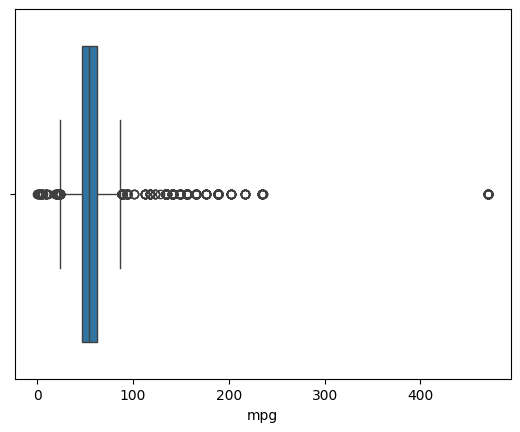

In [22]:
sns.boxplot(data=df,x='mpg')

<Axes: xlabel='engineSize'>

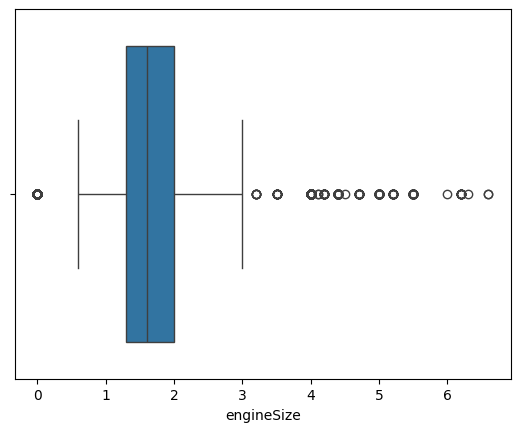

In [23]:
sns.boxplot(data=df,x='engineSize')

In [24]:
print(np.sum(df['engineSize'] == 0))

215


In [25]:
# 1. Calculate the mean of engineSize, EXCLUDING the 0s
# (Otherwise, the 0s will make the average too small)
mean_engine = df[df['engineSize'] > 0]['engineSize'].mean()

# 2. Replace 0 with that mean
df['engineSize'] = df['engineSize'].replace(0, mean_engine)

# 3. Verify there are no 0s left
print(f"Zeros remaining: {(df['engineSize'] == 0).sum()}")
print(f"New mean applied: {mean_engine:.2f}")

Zeros remaining: 0
New mean applied: 1.68


In [26]:
# Only 1 engine size is 6 and 16 engines whose size were > 6 so removing it is better
df = df[(df['engineSize'] < 6)] 

In [27]:
df.shape

(92591, 9)

<Axes: >

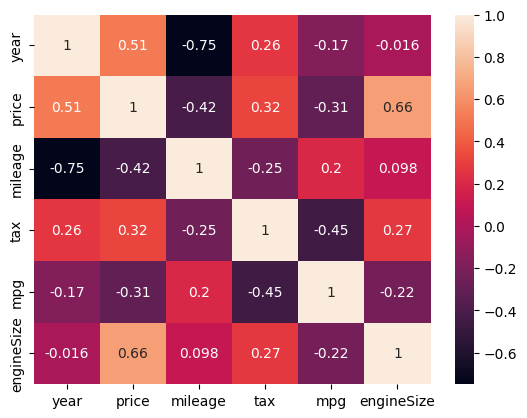

In [28]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# **ML**

In [29]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

In [30]:
total = df['model'].nunique()
print(total) # 174 unique 

174


### Encoding Categorical Data(One-Hot Encoding)

In [31]:
df = pd.get_dummies(data=df,columns=['transmission','fuelType','model'],drop_first=True,dtype=int)
df.head()

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Semi-Auto,fuelType_Hybrid,fuelType_Other,...,model_ Yeti Outdoor,model_ Z4,model_ Zafira,model_ Zafira Tourer,model_ i3,model_ i8,model_180,model_200,model_220,model_230
0,2017,12500,15735,150,55.4,1.4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2016,16500,36203,20,64.2,2.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2016,11000,29946,30,55.4,1.4,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2017,16800,25952,145,67.3,2.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2019,17300,1998,145,49.6,1.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Standard Scaler

In [32]:
X = df.drop(columns=['price'])
y = df['price']

In [33]:
# 1. Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize scaler
scaler = StandardScaler()

# 3. Fit AND Transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# 4. ONLY Transform the test data (
X_test_scaled = scaler.transform(X_test)

In [34]:
# Define your models in a dictionary for easy iteration
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

In [35]:
# Initialize a list to store results
model_comparison = []

# Loop through the dictionary
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate both
    mse = mean_squared_error(y_test, y_pred) # Stays in squared units
    rmse = root_mean_squared_error(y_test, y_pred) # Back to original units
    r2 = r2_score(y_test, y_pred)
    
    model_comparison.append({
        'Model': name,
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })
# Convert to DataFrame
results_df = pd.DataFrame(model_comparison).sort_values(by='R2 Score', ascending=False)
print(results_df)

               Model          MSE     RMSE  R2 Score
0  Linear Regression  12209578.13  3494.22    0.8756
1              Ridge  12228441.51  3496.92    0.8754
2              Lasso  12535189.53  3540.51    0.8723
3         ElasticNet  36802016.35  6066.47    0.6251
